Below is the full pipeline for the backtesting of a trading strategy that trade on CEO stress score (1-5 scale), holding for two days after the earning call. The backtest assumes a rebalance of porfolio each day. (In other word, it's assumed we "realized" the profit each day.)The strategy hold the stock with a CEOs' stress score of three, short the stock with CEOs' stress score above and equal 4, and long the stock with CEOs' stress score below and equal 2. 

The backtest does not include transaction costs, and other market frictions, considering the pool of stocks come from S&P 500, which is quite liquid. 

In [1]:
import pandas as pd

In [3]:
import numpy as np

In [2]:
df = pd.read_csv('../Data/car_1_with_fundamental.csv')

In [4]:
df.shape

(7906, 19)

In [5]:
df[['symbol', 'call_date']].duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates(subset=['symbol', 'call_date'])

In [7]:
df.shape

(7905, 19)

In [8]:
crsp = pd.read_csv('../Data/crsp_daily.csv')
crsp = crsp.drop_duplicates(subset=['TICKER', 'date'])

/var/folders/x0/h2vy4x8s5k3fyhp6bqhf_dv40000gn/T/ipykernel_63946/2557020621.py:1: DtypeWarning: Columns (0: RET) have mixed types. Specify dtype option on import or set low_memory=False.
  crsp = pd.read_csv('../Data/crsp_daily.csv')


In [9]:
df['call_date'] = pd.to_datetime(df['call_date'])
crsp['date'] = pd.to_datetime(crsp['date'])

In [10]:
sp500_daily = (
    crsp[['date', 'vwretd']]
    .dropna()
    .drop_duplicates(subset=['date'])
    .sort_values('date')
    .rename(columns={'vwretd': 'sp500_ret'})
    .reset_index(drop=True)
)

sp500_daily['sp500_gross'] = 1 + sp500_daily['sp500_ret']
sp500_daily['sp500_index'] = 100 * sp500_daily['sp500_gross'].cumprod()

sp500_daily.head()

,date,sp500_ret,sp500_gross,sp500_index
0,2020-01-02,0.007412,1.007412,100.741200
1,2020-01-03,-0.005828,0.994172,100.154080
2,2020-01-06,0.003269,1.003269,100.481484
3,2020-01-07,-0.002147,0.997853,100.265750
4,2020-01-08,0.004028,1.004028,100.669621


In [12]:
df['symbol'].nunique()

489

In [13]:
df['year'].min()

np.int64(2020)

In [14]:
df['year'].max()

np.int64(2025)

In [15]:
df.describe()

,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,vol,mom,POSWORDS,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest
count,7905.000000,7905.000000,7905,5676.000000,7893.000000,7904.000000,7905.000000,7856.000000,7904.000000,7905.000000,7905.000000,7658.000000,7658.000000,7.658000e+03,7753.000000,7753.000000,7753.000000,7753.000000
mean,2022.128526,2.455787,2022-09-22 00:09:28.349146,2.034003,2.531357,2.067687,0.001189,0.020720,0.012588,0.020003,0.006897,10.501892,0.340906,8.994220e+04,0.133100,1.790912,1.657812,16.202889
min,2020.000000,1.000000,2020-01-07 00:00:00,1.000000,1.000000,1.000000,-0.385236,0.006338,-0.703288,0.000000,0.000000,7.220098,0.000153,9.979270e+02,-17.010000,-12.830000,-9.970000,1.000000
25%,2021.000000,1.000000,2021-08-03 00:00:00,2.000000,2.000000,2.000000,-0.019480,0.014132,-0.108865,0.015713,0.004503,9.734804,0.111384,1.121625e+04,0.010000,0.670000,0.610000,12.000000
50%,2022.000000,2.000000,2022-10-25 00:00:00,2.000000,3.000000,2.000000,0.000286,0.017924,-0.004989,0.019370,0.006348,10.352257,0.248961,2.515740e+04,0.070000,1.290000,1.180000,16.000000
75%,2023.000000,3.000000,2023-11-02 00:00:00,2.000000,3.000000,2.000000,0.020375,0.023856,0.108274,0.023708,0.008609,11.093600,0.483893,6.174150e+04,0.190000,2.300000,2.120000,20.000000
max,2025.000000,4.000000,2024-12-19 00:00:00,4.000000,5.000000,5.000000,0.709633,0.105488,2.913348,0.150000,0.078947,15.074600,5.338209,4.210048e+06,11.000000,51.580000,53.390000,42.000000
std,1.356002,1.099135,NaN,0.628884,0.674972,0.604800,0.047466,0.010080,0.200452,0.006359,0.003575,1.036343,0.324796,2.938522e+05,0.529108,2.378882,2.185820,6.453892


In [16]:
df.isna().sum()

symbol                0
year                  0
quarter               0
call_date             0
stress_pr          2229
stress_qa            12
stress_whole          1
car_01                0
vol                  49
mom                   1
POSWORDS              0
NEGWORDS              0
lnmve               247
bm                  247
atq                 247
UE                  152
actual_eps          152
median_forecast     152
numest              152
dtype: int64

In [17]:
df['stress_qa'].value_counts()

stress_qa
3.0    3746
2.0    3338
4.0     415
1.0     391
5.0       3
Name: count, dtype: int64

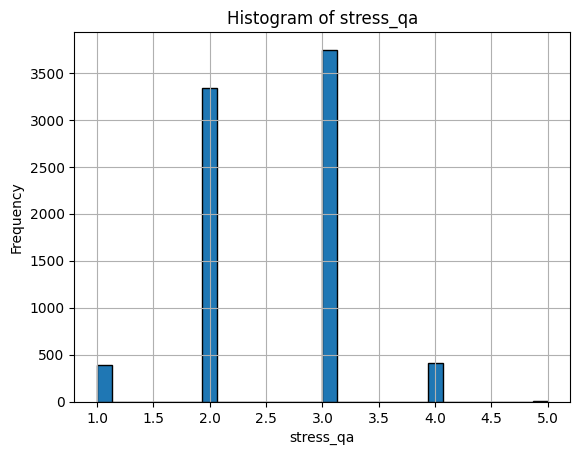

In [18]:
import matplotlib.pyplot as plt

stress_qa_series = pd.to_numeric(df['stress_qa'], errors='coerce').dropna()

stress_qa_series.hist(bins=30, edgecolor='black')
plt.xlabel('stress_qa')
plt.ylabel('Frequency')
plt.title('Histogram of stress_qa')
plt.show()

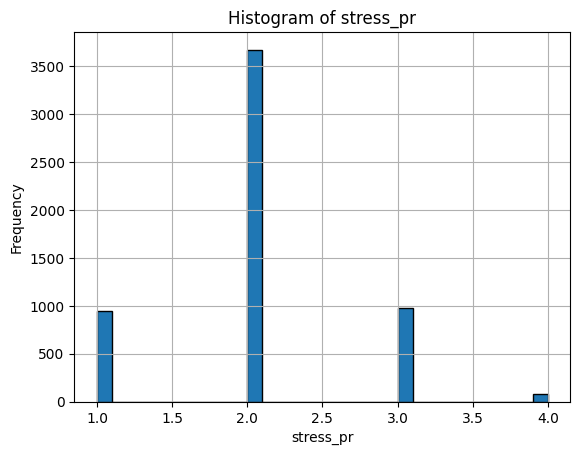

In [19]:
stress_pr_series = pd.to_numeric(df['stress_pr'], errors='coerce').dropna()

stress_pr_series.hist(bins=30, edgecolor='black')
plt.xlabel('stress_pr')
plt.ylabel('Frequency')
plt.title('Histogram of stress_pr')
plt.show()

In [20]:
df['short'] = df['stress_qa'] < 3

In [21]:
df['long'] = df['stress_qa'] > 3

In [22]:
df.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,vol,mom,...,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest,short,long
0,A,2020,1,2020-02-18,2.0,3.0,2.0,-0.007869,0.012197,-0.039716,...,0.008152,10.150252,0.189393,9501.0,0.00,0.81,0.81,15.0,False,False
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.060820,...,0.009410,10.070917,0.201647,9455.0,0.08,0.71,0.63,12.0,False,True
2,A,2020,3,2020-08-18,2.0,3.0,2.0,0.000767,0.029809,0.121183,...,0.008633,10.299754,0.167568,9546.0,0.11,0.78,0.67,13.0,False,False
3,A,2021,1,2021-02-16,1.0,2.0,2.0,0.006804,0.014040,0.068096,...,0.005454,10.508908,0.131112,9674.0,0.18,1.06,0.88,16.0,True,False
4,A,2021,2,2021-05-25,1.0,3.0,1.0,0.024898,0.013485,0.064456,...,0.005383,10.610212,0.118628,10398.0,0.15,0.97,0.82,16.0,False,False


In [23]:
df.groupby('call_date')['long'].value_counts()

call_date   long 
2020-01-07  True     1
2020-01-08  True     1
            False    1
2020-01-23  False    2
2020-01-27  False    1
                    ..
2024-12-11  False    1
2024-12-12  False    2
2024-12-18  False    2
2024-12-19  False    9
            True     2
Name: count, Length: 1110, dtype: int64

In [24]:
df['long'] = df['long'].apply(lambda x: 1 if x==True else 0)
df['short'] = df['short'].apply(lambda x: 1 if x==True else 0)

In [25]:
df['long'].unique()

array([0, 1])

In [26]:
df.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,vol,mom,...,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest,short,long
0,A,2020,1,2020-02-18,2.0,3.0,2.0,-0.007869,0.012197,-0.039716,...,0.008152,10.150252,0.189393,9501.0,0.00,0.81,0.81,15.0,0,0
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.060820,...,0.009410,10.070917,0.201647,9455.0,0.08,0.71,0.63,12.0,0,1
2,A,2020,3,2020-08-18,2.0,3.0,2.0,0.000767,0.029809,0.121183,...,0.008633,10.299754,0.167568,9546.0,0.11,0.78,0.67,13.0,0,0
3,A,2021,1,2021-02-16,1.0,2.0,2.0,0.006804,0.014040,0.068096,...,0.005454,10.508908,0.131112,9674.0,0.18,1.06,0.88,16.0,1,0
4,A,2021,2,2021-05-25,1.0,3.0,1.0,0.024898,0.013485,0.064456,...,0.005383,10.610212,0.118628,10398.0,0.15,0.97,0.82,16.0,0,0


In [27]:
# building a table to filter out events to focus on (The backtesting require per call_date to have at least 2 long and 2 short to enter. The number is quite arbitrary.)
summary  = df.groupby('call_date').agg(
    total_long=('long', 'sum'),
    total_short=('short', 'sum')
)

In [28]:
summary

,total_long,total_short
call_date,,
2020-01-07,1,0
2020-01-08,1,1
2020-01-23,0,2
2020-01-27,0,1
2020-01-28,0,1
...,...,...
2024-12-10,0,0
2024-12-11,0,0
2024-12-12,0,1


In [29]:
summary['total_positions'] = summary['total_long'] + summary['total_short']

In [30]:
summary.head()

,total_long,total_short,total_positions
call_date,,,
2020-01-07,1,0,1
2020-01-08,1,1,2
2020-01-23,0,2,2
2020-01-27,0,1,1
2020-01-28,0,1,1


In [31]:
# If we require there to be 2 long and 2 short for enter, there would be 91 call_dates. 
summary[(summary['total_long'] >= 2) & (summary['total_short'] >= 2)]

,total_long,total_short,total_positions
call_date,,,
2020-04-23,3,4,7
2020-04-30,2,5,7
2020-05-01,4,2,6
2020-05-05,5,3,8
2020-05-06,2,5,7
...,...,...,...
2024-10-15,2,4,6
2024-10-30,5,27,32
2024-10-31,3,28,31


In [32]:
# getting the qualified date as index
trading_date = summary[(summary['total_long'] >= 2) & (summary['total_short'] >= 2)].index

In [33]:
trading_date

DatetimeIndex(['2020-04-23', '2020-04-30', '2020-05-01', '2020-05-05',
               '2020-05-06', '2020-05-07', '2020-05-21', '2020-07-28',
               '2020-07-29', '2020-08-04', '2020-08-06', '2020-10-27',
               '2020-10-29', '2021-02-11', '2021-02-18', '2021-02-25',
               '2021-04-28', '2021-04-29', '2021-05-05', '2021-07-29',
               '2021-08-05', '2021-10-19', '2021-10-26', '2021-10-29',
               '2021-11-02', '2021-11-04', '2022-01-25', '2022-01-26',
               '2022-02-10', '2022-02-24', '2022-04-26', '2022-04-27',
               '2022-04-28', '2022-05-03', '2022-05-04', '2022-05-05',
               '2022-07-21', '2022-07-26', '2022-07-27', '2022-08-01',
               '2022-10-26', '2022-10-27', '2022-11-02', '2022-11-04',
               '2023-01-25', '2023-01-31', '2023-02-01', '2023-02-14',
               '2023-02-22', '2023-04-25', '2023-04-26', '2023-04-27',
               '2023-05-02', '2023-05-04', '2023-07-26', '2023-07-27',
      

In [34]:
# convert to dataframe for later data retrieving.
call_datess = pd.DataFrame(trading_date)

In [35]:
call_datess

,call_date
0,2020-04-23
1,2020-04-30
2,2020-05-01
3,2020-05-05
4,2020-05-06
...,...
86,2024-10-15
87,2024-10-30
88,2024-10-31
89,2024-11-05


In [36]:
# this data includes all the companies that has earning call within the qualified call_dates. 
data = df[df['call_date'].isin(call_datess['call_date'])]

In [37]:
# checking duplicates
data[['symbol', 'call_date']].duplicated().sum()

np.int64(0)

In [38]:
data[data.duplicated(subset=['symbol', 'call_date'], keep=False)]

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,vol,mom,...,NEGWORDS,lnmve,bm,atq,UE,actual_eps,median_forecast,numest,short,long


In [39]:
data.shape

(2913, 21)

calculating win rate. 

In [40]:
"""
for each call_date and firm, we calculate their next two days' return. (adjust according to long/short)
call_date, firm, return
"""

crsp['date']   = pd.to_datetime(crsp['date'])
crsp['RET']    = pd.to_numeric(crsp['RET'],    errors='coerce')
data['call_date'] = pd.to_datetime(data['call_date'])
list = []

for i, (_,row) in enumerate(data.iterrows()):
    call_date = row['call_date']
    symbol = row['symbol']
    firm = crsp[crsp['TICKER'] == symbol].reset_index(drop=True)
    
    # look for day0: the immediate trading day after the earning call date
    day0_candidates = firm[(firm['date'] > call_date) & (firm['date'] <= call_date + pd.Timedelta(days=5))]
    day0_idx = day0_candidates.index[0]

    if day0_idx + 1 >= len(firm):
        continue

    day1_idx = day0_idx + 1
    day0     = firm.loc[day0_idx, 'date']
    day1   = firm.loc[day1_idx, 'date']

    # Create a window [0,1]
    window_01 = firm.iloc[day0_idx:day1_idx + 1]
    
    # Calculating the return for the window, then store it to the data. 
    window_01['gross_ret'] = 1 + window_01['RET']
    ret = window_01['gross_ret'].cumprod().iloc[-1] - 1
    
    if row['short'] == 1:
        ret = -1 * ret
    
    row['trade_ret'] = ret
    list.append(row)
   
# store it as final_data including the ret for each trade. 
final_data = pd.DataFrame(list)
        

In [42]:
final_data.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,vol,mom,...,lnmve,bm,atq,UE,actual_eps,median_forecast,numest,short,long,trade_ret
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.060820,...,10.070917,0.201647,9455.0,0.08,0.71,0.63,12.0,0,1,0.066626
14,A,2024,1,2024-02-27,2.0,3.0,2.0,0.033073,0.017602,-0.025639,...,10.548619,0.162309,10948.0,0.07,1.29,1.22,15.0,0,0,0.036289
17,AAL,2020,1,2020-04-30,3.0,3.0,3.0,-0.158983,0.078792,-0.543462,...,9.377024,0.013543,61175.0,-0.65,-2.65,-2.00,13.0,0,0,-0.182349
25,AAL,2022,2,2022-07-21,NaN,2.0,2.0,-0.014936,0.041264,0.003291,...,9.377024,0.013543,61175.0,0.00,0.76,0.76,13.0,1,0,0.023437
28,AAL,2023,1,2023-04-27,2.0,3.0,2.0,0.071001,0.025941,-0.132064,...,9.377024,0.013543,61175.0,0.01,0.05,0.04,15.0,0,0,0.078415


In [43]:
final_data.isna().sum()

symbol               0
year                 0
quarter              0
call_date            0
stress_pr          707
stress_qa            7
stress_whole         1
car_01               0
vol                  7
mom                  0
POSWORDS             0
NEGWORDS             0
lnmve               90
bm                  90
atq                 90
UE                  30
actual_eps          30
median_forecast     30
numest              30
short                0
long                 0
trade_ret            0
dtype: int64

In [44]:
final_data['gross'] = 1 + final_data['trade_ret']

In [45]:
final_data.groupby('call_date').agg(
    total_long=('long', 'sum'),
    total_short=('short', 'sum'))

,total_long,total_short
call_date,,
2020-04-23,3,4
2020-04-30,2,5
2020-05-01,4,2
2020-05-05,5,3
2020-05-06,2,5
...,...,...
2024-10-15,2,4
2024-10-30,5,27
2024-10-31,3,28


In [46]:
win_trades = final_data[final_data['trade_ret'] > 0]

In [47]:
win_trades.shape

(1465, 23)

In [48]:
average_win_percent = win_trades['trade_ret'].mean()
average_win_percent

np.float64(0.032357728320681914)

In [49]:
average_loss_percent = final_data[final_data['trade_ret'] < 0]['trade_ret'].mean()
average_loss_percent

np.float64(-0.034830538372415745)

In [50]:
# win trade percentage
win_trades.shape[0] / data.shape[0]

0.5029179539993134

backtesting

In [51]:
# build entry and exit date for each event
for idx, row in data.iterrows():
    call_date = row['call_date']
    symbol = row['symbol']
    firm_data = crsp[crsp['TICKER'] == symbol].reset_index(drop=True)
    
    # Find the next two trading days after the call_date
    next_days = firm_data[firm_data['date'] > call_date].head(2)
    
    if len(next_days) < 2:
        print(f"Not enough trading days for {symbol} after {call_date}")
        continue
    
    entry_date = next_days.iloc[0]['date']
    exit_date = next_days.iloc[1]['date']
    
    data.at[idx, 'entry_date'] = entry_date
    data.at[idx, 'exit_date'] = exit_date

In [52]:
backtesting_data = data.merge(crsp, how="left", left_on="symbol", right_on="TICKER")

In [53]:
backtesting_data.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,vol,mom,...,short,long,entry_date,exit_date,PERMNO,date,TICKER,COMNAM,RET,vwretd
0,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.06082,...,0,1,2020-05-22,2020-05-26,87432,2020-01-02,A,AGILENT TECHNOLOGIES INC,0.007502,0.007412
1,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.06082,...,0,1,2020-05-22,2020-05-26,87432,2020-01-03,A,AGILENT TECHNOLOGIES INC,-0.016056,-0.005828
2,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.06082,...,0,1,2020-05-22,2020-05-26,87432,2020-01-06,A,AGILENT TECHNOLOGIES INC,0.002956,0.003269
3,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.06082,...,0,1,2020-05-22,2020-05-26,87432,2020-01-07,A,AGILENT TECHNOLOGIES INC,0.003065,-0.002147
4,A,2020,2,2020-05-21,2.0,4.0,2.0,0.049746,0.032435,0.06082,...,0,1,2020-05-22,2020-05-26,87432,2020-01-08,A,AGILENT TECHNOLOGIES INC,0.009873,0.004028


In [54]:
# save the relevant data for backtesting.

lis = []
for i, ((call_date, symbol), group) in enumerate(backtesting_data.groupby(['call_date', 'symbol'])):
    # we want the data for the particular event
    event_data = backtesting_data[(backtesting_data['symbol'] == symbol) & 
                                  (backtesting_data['call_date'] == call_date)]

    # we then only need the data from the entry to exit
    positions_table = event_data[(event_data['date'] >= event_data['entry_date'].iloc[0]) &
                                 (event_data['date'] <= event_data['exit_date'].iloc[0])]

    # append to final list
    lis.append(positions_table)                    
    

In [55]:
positions_df = pd.concat(lis, ignore_index=True)

In [56]:
positions_df.head()

,symbol,year,quarter,call_date,stress_pr,stress_qa,stress_whole,car_01,vol,mom,...,short,long,entry_date,exit_date,PERMNO,date,TICKER,COMNAM,RET,vwretd
0,BX,2020,1,2020-04-23,NaN,2.0,2.0,0.030335,0.052409,0.018303,...,1,0,2020-04-24,2020-04-27,92108,2020-04-24,BX,BLACKSTONE GROUP INC,0.000000,0.013045
1,BX,2020,1,2020-04-23,NaN,2.0,2.0,0.030335,0.052409,0.018303,...,1,0,2020-04-24,2020-04-27,92108,2020-04-27,BX,BLACKSTONE GROUP INC,0.061119,0.017511
2,COF,2020,1,2020-04-23,3.0,4.0,3.0,0.094288,0.063098,-0.365057,...,0,1,2020-04-24,2020-04-27,81055,2020-04-24,COF,CAPITAL ONE FINANCIAL CORP,0.067288,0.013045
3,COF,2020,1,2020-04-23,3.0,4.0,3.0,0.094288,0.063098,-0.365057,...,0,1,2020-04-24,2020-04-27,81055,2020-04-27,COF,CAPITAL ONE FINANCIAL CORP,0.054141,0.017511
4,DFS,2020,1,2020-04-23,NaN,3.0,3.0,0.044460,0.076823,-0.467266,...,0,0,2020-04-24,2020-04-27,92121,2020-04-24,DFS,DISCOVER FINANCIAL SERVICES,0.040494,0.013045


### first strategy: 

In [57]:
list_one = []

for date in positions_df['date'].unique():
    # getting the firms associate with the call_date
    day_data = positions_df[positions_df['date'] == date]
    
    # calculating number of long and short stock
    n_long = day_data['long'].sum()
    n_short = day_data['short'].sum()
    
    
    # calculating long and short return for that call_date
    # long_ret = (long_firms['RET'] / n_long).sum()
    # short_ret = (short_firms['RET'] / n_short).sum()
    long_ret = (day_data[day_data['long'] == 1]['RET'] / n_long).sum()
    short_ret = (day_data[day_data['short'] == 1]['RET'] / n_short).sum()
    
    # calculating total return
    total_return = 0.5 * long_ret - 0.5 * short_ret
    
    # append the tot_ret for later making of dataframe
    dict = {"date": date, "total_ret": total_return}
    
    list_one.append(dict)

daily_series = pd.DataFrame(list_one)

In [58]:
crsp['date'].unique()

<DatetimeArray>
['2020-01-02 00:00:00', '2020-01-03 00:00:00', '2020-01-06 00:00:00',
 '2020-01-07 00:00:00', '2020-01-08 00:00:00', '2020-01-09 00:00:00',
 '2020-01-10 00:00:00', '2020-01-13 00:00:00', '2020-01-14 00:00:00',
 '2020-01-15 00:00:00',
 ...
 '2024-12-17 00:00:00', '2024-12-18 00:00:00', '2024-12-19 00:00:00',
 '2024-12-20 00:00:00', '2024-12-23 00:00:00', '2024-12-24 00:00:00',
 '2024-12-26 00:00:00', '2024-12-27 00:00:00', '2024-12-30 00:00:00',
 '2024-12-31 00:00:00']
Length: 1258, dtype: datetime64[us]

In [59]:
calendar_exp = pd.DataFrame(crsp['date'].unique(), columns=['date'])

In [ ]:
daily_series['date'] = pd.to_datetime(daily_series['date'])

trading_day = pd.DataFrame(crsp['date'].unique(), columns=['date'])

daily_full = trading_day.merge(
    daily_series[['date', 'total_ret']],
    on='date',
    how='left'
)

daily_full['total_ret'] = daily_full['total_ret'].fillna(0)
daily_full['gross'] = 1 + daily_full['total_ret']
daily_full['growth'] = daily_full['gross'].cumprod()
daily_full['index'] = 100 * daily_full['growth']
daily_full.head()

,date,total_ret,gross,growth,index
0,2020-01-02,0.0,1.0,1.0,100.0
1,2020-01-03,0.0,1.0,1.0,100.0
2,2020-01-06,0.0,1.0,1.0,100.0
3,2020-01-07,0.0,1.0,1.0,100.0
4,2020-01-08,0.0,1.0,1.0,100.0


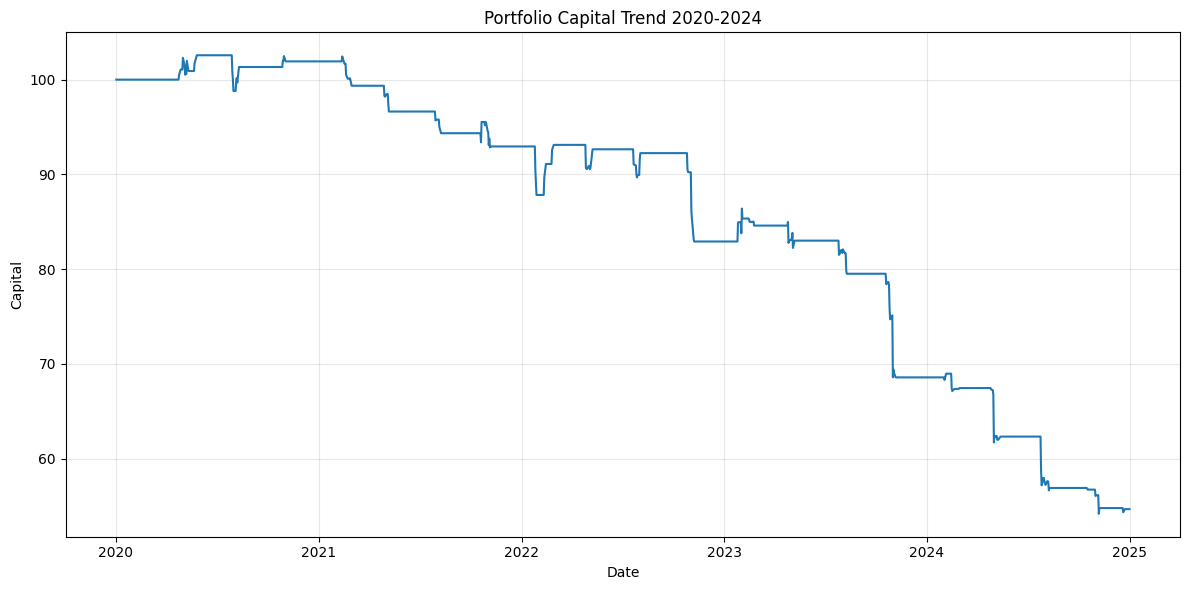

In [ ]:
# Ai
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_full['date'], daily_full['index'], linewidth=1.5)
plt.title('Portfolio Capital Trend 2020-2024')
plt.xlabel('Date')
plt.ylabel('Capital')
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [66]:
print("final return: ", (daily_full['index'].iloc[-1] - daily_full['index'].iloc[0])/daily_full['index'].iloc[0])

final return:  -0.45323077117187394


second strategy: don't balance long and short in each trading day, allocate weights for long and short according to the number of stocks in each category.

In [67]:
second_strategy = []

for date in positions_df['date'].unique():
    # getting the firms associate with the call_date
    day_data = positions_df[positions_df['date'] == date]
    
    # calculating number of long and short stock
    n_long = day_data['long'].sum()
    n_short = day_data['short'].sum()
    
    
    # calculating long and short return for that call_date
    # long_ret = (long_firms['RET'] / n_long).sum()
    # short_ret = (short_firms['RET'] / n_short).sum()
    long_ret = (day_data[day_data['long'] == 1]['RET'] / n_long).sum()
    short_ret = (day_data[day_data['short'] == 1]['RET'] / n_short).sum()
    
    # calculating total return
    total_return = (n_long / (n_long + n_short)) * long_ret - (n_short / (n_long + n_short)) * short_ret
    
    # append the tot_ret for later making of dataframe
    dict = {"date": date, "total_ret": total_return}
    
    second_strategy.append(dict)

daily_series = pd.DataFrame(second_strategy)

In [68]:
daily_series.head()

,date,total_ret
0,2020-04-24,0.001085
1,2020-04-27,0.002848
2,2020-05-01,0.028127
3,2020-05-04,-0.007397
4,2020-05-05,-0.007727


In [72]:
daily_series['date'] = pd.to_datetime(daily_series['date'])

calendar = pd.DataFrame({
    'date': pd.date_range('2020-01-01', '2024-12-31', freq='B')
})

daily_full = calendar.merge(
    daily_series[['date', 'total_ret']],
    on='date',
    how='left'
)

daily_full['total_ret'] = daily_full['total_ret'].fillna(0)
daily_full['gross'] = 1 + daily_full['total_ret']
daily_full['growth'] = daily_full['gross'].cumprod()
daily_full['index'] = 100 * daily_full['growth']

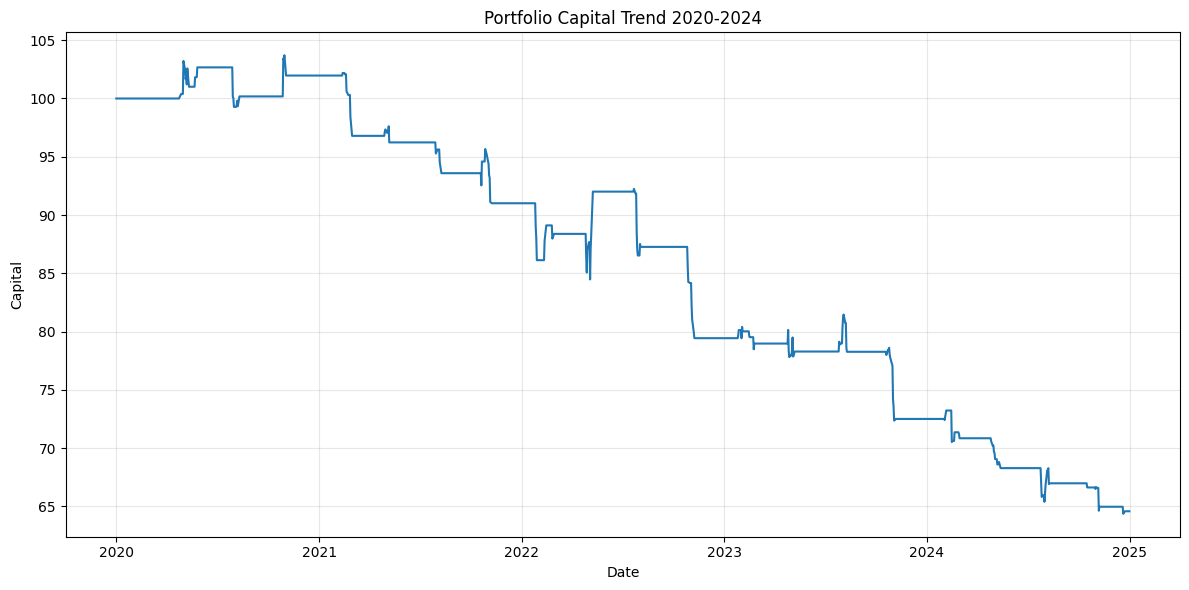

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_full['date'], daily_full['index'], linewidth=1.5)
plt.title('Portfolio Capital Trend 2020-2024')
plt.xlabel('Date')
plt.ylabel('Capital')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
daily_series['gross'] = 1 + daily_series['total_ret']
final_return = daily_series['gross'].cumprod().iloc[-1] - 1
final_return

np.float64(-0.354197161912966)

In [76]:
sp500_daily = (
    crsp[['date', 'vwretd']]
    .dropna()
    .drop_duplicates(subset=['date'])
    .sort_values('date')
    .rename(columns={'vwretd': 'sp500_ret'})
    .reset_index(drop=True)
)

sp500_daily['sp500_gross'] = 1 + sp500_daily['sp500_ret']
sp500_daily['sp500_index'] = 100 * sp500_daily['sp500_gross'].cumprod()

sp500_daily.head()

,date,sp500_ret,sp500_gross,sp500_index
0,2020-01-02,0.007412,1.007412,100.741200
1,2020-01-03,-0.005828,0.994172,100.154080
2,2020-01-06,0.003269,1.003269,100.481484
3,2020-01-07,-0.002147,0.997853,100.265750
4,2020-01-08,0.004028,1.004028,100.669621


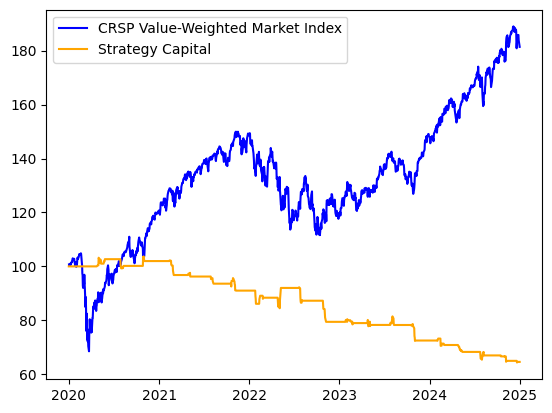

In [78]:
plt.plot(sp500_daily['date'], sp500_daily['sp500_index'], label='CRSP Value-Weighted Market Index', color='blue')
plt.plot(daily_full['date'], daily_full['index'], label='Strategy Capital', color='orange')
plt.legend()